### Plot SynShorkie performance 

### Main results figure

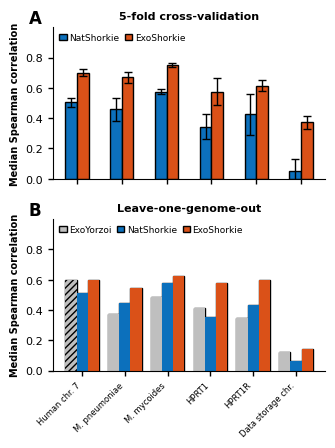

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Data
# -----------------------------
genomes = ['Human chr. 7', 'M. pneumoniae', 'M. mycoides', 'HPRT1', 'HPRT1R', 'Data storage chr.']
x = np.arange(len(genomes))

# Panel A
A_models = ['NatShorkie', 'ExoShorkie']

A_means = {
    'NatShorkie': np.array([0.5048, 0.4577, 0.5753, 0.3447, 0.4253, 0.0483]),
    'ExoShorkie': np.array([0.7011, 0.6701, 0.7514, 0.5743, 0.6136, 0.3730]),
}
A_std = {
    'NatShorkie': np.array([0.0289, 0.07629, 0.0174, 0.0843, 0.1364, 0.0827]),
    'ExoShorkie': np.array([0.0235, 0.0354, 0.0146, 0.0894, 0.0365, 0.0414]),
}

# Panel B
B_models = ["ExoYorzoi", "NatShorkie", "ExoShorkie"]
B_means = {
    "ExoYorzoi": np.array([0.6010, 0.3730, 0.4870, 0.4133, 0.3459, 0.1200]),
    "NatShorkie": np.array([0.5142, 0.4459, 0.5776, 0.3562, 0.4332, 0.0647]),
    "ExoShorkie": np.array([0.5968, 0.5444, 0.6217, 0.5780, 0.6000, 0.1425]),
}

# Colors (same hex values you provided; keys aligned to your labels)
colors_A = {
    "NatShorkie": "#0c70bc",
    "ExoShorkie": "#da5118",
}
colors_B = {
    "ExoYorzoi": "#bfbfbf",
    "NatShorkie": "#0c70bc",
    "ExoShorkie": "#da5118",
    #"ExoShorkie": "#6BAED6",
}

# -----------------------------
# Plot
# -----------------------------
fig, (axA, axB) = plt.subplots(
    2, 1, figsize=(3.45, 4.6),)

for ax in (axA, axB):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0.0, 1)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
    ax.tick_params(axis="y", labelsize=8, width=1)
    ax.tick_params(axis="x", labelsize=8, width=1)

bar_w = 0.26

# Offsets per panel (match #bars)
offsets_A = np.array([-bar_w/2, +bar_w/2])          # 2 bars
offsets_B = np.array([-bar_w, 0.0, +bar_w])         # 3 bars

# ---- Panel A ----
for k, m in enumerate(A_models):
    axA.bar(
        x + offsets_A[k], A_means[m], width=bar_w,
        color=colors_A[m], edgecolor="black", linewidth=1
    )
    axA.errorbar(
        x + offsets_A[k], A_means[m], yerr=A_std[m],
        fmt="none", ecolor="black", elinewidth=1.0, capsize=3, zorder=10
    )

axA.set_title("5-fold cross-validation", fontsize=8, fontweight="bold")
axA.set_ylabel("Median Spearman correlation", fontsize=7,fontweight="bold")
axA.set_xticks(x)
axA.set_xticklabels([])
axA.set_ylim(0.0, 1)

axA.text(-0.09, 1.12, "A", transform=axA.transAxes,
         fontsize=12, fontweight="bold", va="top", ha="left")

# ---- Panel B ----
for k, m in enumerate(B_models):
    axB.bar(
        x + offsets_B[k], B_means[m], width=bar_w,
        color=colors_B[m], edgecolor="black", linewidth=1
    )

axB.set_ylabel("Median Spearman correlation", fontweight="bold", fontsize=7)
# axB.set_xlabel("Exogenous sequence origin", fontsize=15)
axB.set_title("Leave-one-genome-out", fontsize=8, fontweight="bold")
axB.set_xticks(x)
axB.set_xticklabels(genomes, fontsize=6, rotation=45, ha="right")

axB.text(-0.09, 1.12, "B", transform=axB.transAxes,
         fontsize=12, fontweight="bold", va="top", ha="left")

# --- Text inside SynYorzoi bar for Human Chr. 7 ---
# axB.text(
#     x[0] + offsets_B[0],                 # bar center (SynYorzoi, chr7)
#     B_means["SynYorzoi"][0] * 0.5,        # halfway up the bar
#     "Train\ndata",
#     ha="center",
#     va="center",
#     alpha=0.75,
#     fontsize=10,
#     color="black",
#     fontweight="bold",
# )

# -----------------------------
# Legends: FORCE SAME POSITION
# -----------------------------
LEG_LOC = "upper left"
LEG_BBOX = (0.005, 0.995)

handles_A = [Patch(facecolor=colors_A[m], edgecolor="black", label=m) for m in A_models]
axA.legend(
    handles=handles_A,
    frameon=False,
    fontsize=6.5,
    loc=LEG_LOC,
    bbox_to_anchor=LEG_BBOX,
    borderaxespad=0.15,
    handlelength=0.8,
    handleheight=0.6,
    handletextpad=0.3,
    ncol=2,
    columnspacing=0.6
)

for k, m in enumerate(B_models):
    for i in range(len(genomes)):
        hatch = None
        if m == "ExoYorzoi" and i == 0:  # ONLY ExoYorzoi on Human Chr. 7
            hatch = "/////"

        axB.bar(
            x[i] + offsets_B[k],
            B_means[m][i],
            width=bar_w,
            color=colors_B[m],
            edgecolor="black",
            linewidth=0.00001,
            hatch=hatch
        )

handles_B = [Patch(facecolor=colors_B[m], edgecolor="black", label=m) for m in B_models]
axB.legend(
    handles=handles_B,
    frameon=False,
    fontsize=6.5,
    loc=LEG_LOC,
    bbox_to_anchor=LEG_BBOX,
    borderaxespad=0.15,
    handlelength=0.8,
    handleheight=0.6,
    handletextpad=0.3,
    ncol=3,
    columnspacing=0.6
)

plt.tight_layout()
plt.savefig("Figure_3.png", dpi=300, bbox_inches="tight")
plt.show()

### Ablation experiment figure

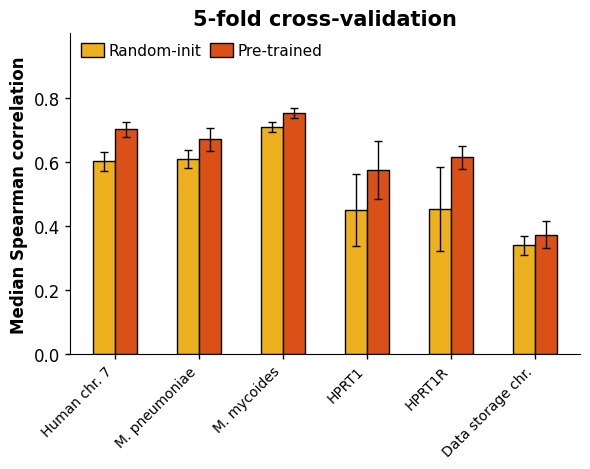

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Data (UNCHANGED)
# -----------------------------
genomes = ['Human chr. 7', 'M. pneumoniae', 'M. mycoides', 'HPRT1', 'HPRT1R', 'Data storage chr.']
x = np.arange(len(genomes))

A_models = ['Random-init', 'Pre-trained']

A_means = {
    'Random-init': np.array([0.6015, 0.60868, 0.70825, 0.4487, 0.4516, 0.3398]),
    'Pre-trained': np.array([0.7011, 0.6701, 0.7514, 0.5743, 0.6136, 0.3730]),
}
A_std = {
    'Random-init': np.array([0.0291, 0.0273, 0.01628, 0.1119, 0.1313, 0.0298]),
    'Pre-trained': np.array([0.0235, 0.0354, 0.0146, 0.0894, 0.0365, 0.0414]),
}

colors_A = {
    "Random-init": "#edb11f",
    "Pre-trained": "#da5118",
}

# -----------------------------
# Plot (single panel)
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 4.8))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0.0, 1)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
ax.tick_params(axis="y", labelsize=12, width=1)
ax.tick_params(axis="x", labelsize=14, width=1)
ax.set_title("5-fold cross-validation", fontsize=15, fontweight="bold")

bar_w = 0.26
offsets = np.array([-bar_w/2, +bar_w/2])  # 2 bars

for k, m in enumerate(A_models):
    ax.bar(
        x + offsets[k], A_means[m], width=bar_w,
        color=colors_A[m], edgecolor="black", linewidth=1
    )
    ax.errorbar(
        x + offsets[k], A_means[m], yerr=A_std[m],
        fmt="none", ecolor="black", elinewidth=1.0, capsize=3, zorder=10
    )

ax.set_ylabel("Median Spearman correlation", fontsize=12, fontweight="bold")
# ax.set_xlabel("Exogenous genome origin", fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(genomes,fontsize=10, rotation=45, ha="right")

# Legend (same style/position)
LEG_LOC = "upper left"
LEG_BBOX = (0.005, 0.995)
handles = [Patch(facecolor=colors_A[m], edgecolor="black", label=m) for m in A_models]
ax.legend(
    handles=handles,
    frameon=False,
    fontsize=11,
    loc=LEG_LOC,
    bbox_to_anchor=LEG_BBOX,
    borderaxespad=0.15,
    handlelength=1.5,
    handleheight=1,
    handletextpad=0.3,
    ncol=2,
    columnspacing=0.6
)

plt.tight_layout()
plt.savefig("Figure_4.png", dpi=300, bbox_inches="tight")
plt.show()